## Tarea 8: Transformers — Soluciones

Soluciones de los ejercicios rápidos de la sección 10 de `notebooks/Transformers.ipynb`, que es lo que pide la parte de Python de `tareas/Tarea8.ipynb`. Se reutilizan exactamente los componentes construidos en ese notebook (tokenizador char-level, positional encoding sinusoidal, atención escalada con máscara causal, multi-head, `TinyGPT`, bucle de entrenamiento con AdamW, `generate` y `plot_attention`), empaquetados en funciones para poder variar un factor a la vez manteniendo semilla, splits y presupuesto de pasos fijos. Úsalas para verificar tu trabajo (o el de tu agente) después de intentarlo.

Protocolo experimental:

- semilla fija (`SEED = 1234`) y mismo split train/val (90/10 secuencial),
- mismo presupuesto de entrenamiento en todas las corridas: **200 pasos, AdamW, `lr=3e-4`, `batch_size=32`, `block_size=64`**,
- baseline: `d_model=128, num_layers=2, num_heads=4, d_ff=256`,
- se varía **un solo** hiperparámetro por experimento,
- cada experimento termina con una celda de **Interpretación**.

## 0) Configuración común: componentes reutilizados del notebook de clase

In [1]:
# ---------------------------
# Imports & utilidades básicas (idénticas al notebook de Transformers)
# ---------------------------
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


def set_seed(seed: int = 1234) -> None:
    """Fija semillas para reproducibilidad en random, numpy y torch (CPU/GPU/MPS)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def find_device() -> torch.device:
    """CUDA > MPS (GPU de Apple/Metal) > CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


device = find_device()
SEED = 1234
set_seed(SEED)
print("DEVICE:", device)
print("torch:", torch.__version__)

DEVICE: mps
torch: 2.14.0


In [2]:
# -----------------------------------------
# Tokenizador char-level + dataset autoregresivo
# (mismo contenido que la sección 1 del notebook, encapsulado en una clase
#  para poder cambiar de corpus sin tocar variables globales)
# -----------------------------------------
class CharTokenizer:
    """Tokenizador a nivel de carácter: construye el vocabulario a partir del corpus."""

    def __init__(self, text: str):
        self.chars = sorted(list(set(text)))
        self.stoi = {ch: i for i, ch in enumerate(self.chars)}
        self.itos = {i: ch for ch, i in self.stoi.items()}
        self.vocab_size = len(self.chars)

    def encode(self, s: str) -> list[int]:
        return [self.stoi[c] for c in s]

    def decode(self, ids: list[int]) -> str:
        return "".join(self.itos[i] for i in ids)


def make_dataset(text: str, tok: CharTokenizer, block_size: int = 64, step: int = 1):
    """
    Pares (X, Y) para LM autoregresivo: Y es X corrido una posición a la derecha.
    X, Y: [N, block_size] de dtype long.
    """
    data = torch.tensor(tok.encode(text), dtype=torch.long)
    X, Y = [], []
    for i in range(0, len(data) - block_size - 1, step):
        X.append(data[i : i + block_size])
        Y.append(data[i + 1 : i + block_size + 1])
    return torch.stack(X), torch.stack(Y)


def split_dataset(X, Y, frac_train: float = 0.9):
    """Split secuencial 90/10 (mismo criterio que el notebook de clase)."""
    n = int(frac_train * len(X))
    return X[:n], Y[:n], X[n:], Y[n:]

In [3]:
# ---------------------------------------------------------------
# Positional Encoding, atención, multi-head, bloque y TinyGPT
# Único cambio respecto al notebook: la máscara causal es un FLAG que se
# propaga desde TinyGPT(causal=...) hasta scaled_dot_product_attention,
# para poder apagarla en el ejercicio (v).
# ---------------------------------------------------------------
class PositionalEncoding(nn.Module):
    """Codificación posicional sinusoidal (Vaswani et al., 2017). Sin parámetros entrenables."""

    def __init__(self, d_model: int, max_len: int = 2048):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # [1, max_len, d_model]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        T = x.size(1)
        return x + self.pe[:, :T, :]


def scaled_dot_product_attention(Q, K, V, causal_mask: bool = False):
    """
    Attention(Q,K,V) = softmax(QK^T / sqrt(d_h)) V, con máscara causal opcional.
    Q,K,V: [B, h, T, d_h] -> out: [B, h, T_q, d_h], A: [B, h, T_q, T_k].
    """
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    if causal_mask:
        T_k = scores.size(-1)
        mask = torch.triu(torch.ones(T_k, T_k, device=scores.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float("-inf"))
    A = torch.softmax(scores, dim=-1)
    out = torch.matmul(A, V)
    return out, A


class MultiHeadAttention(nn.Module):
    """Multi-Head Attention: proyecta a h cabezas de dimensión d_model//h y devuelve (out, A)."""

    def __init__(self, d_model: int, num_heads: int, causal: bool):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.causal = causal
        self.Wq = nn.Linear(d_model, d_model, bias=False)
        self.Wk = nn.Linear(d_model, d_model, bias=False)
        self.Wv = nn.Linear(d_model, d_model, bias=False)
        self.Wo = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x: torch.Tensor, context: torch.Tensor | None = None):
        if context is None:
            Q_in = K_in = V_in = x
        else:
            Q_in, K_in, V_in = x, context, context

        B, T_q, C = Q_in.shape
        T_k = K_in.shape[1]

        Q = self.Wq(Q_in).view(B, T_q, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.Wk(K_in).view(B, T_k, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.Wv(V_in).view(B, T_k, self.num_heads, self.head_dim).transpose(1, 2)

        out_heads, A = scaled_dot_product_attention(
            Q, K, V, causal_mask=self.causal and (context is None)
        )
        out = out_heads.transpose(1, 2).contiguous().view(B, T_q, C)
        return self.Wo(out), A


class FeedForward(nn.Module):
    """MLP posición-a-posición: d_model -> d_ff -> d_model, con GELU y dropout."""

    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    """Bloque decoder-only estilo GPT con pre-LayerNorm y conexiones residuales."""

    def __init__(self, d_model: int, num_heads: int, d_ff: int, causal: bool):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, num_heads, causal=causal)
        self.ln1 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, d_ff)
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x, context=None, return_attn: bool = False):
        attn_out, A = self.attn(self.ln1(x), context=context)
        x = x + attn_out
        x = x + self.ff(self.ln2(x))
        if return_attn:
            return x, A
        return x


class TinyGPT(nn.Module):
    """
    Mini GPT (decoder-only) char-level.

    `causal=True` reproduce el modelo del notebook de clase; `causal=False` apaga la
    máscara triangular en TODAS las capas (ejercicio v).
    """

    def __init__(
        self,
        vocab_size: int,
        d_model: int = 128,
        num_layers: int = 2,
        num_heads: int = 4,
        d_ff: int = 256,
        max_len: int = 512,
        dropout: float = 0.1,
        causal: bool = True,
    ):
        super().__init__()
        self.causal = causal
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=max_len)
        self.blocks = nn.ModuleList(
            [TransformerBlock(d_model, num_heads, d_ff, causal=causal) for _ in range(num_layers)]
        )
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, idx: torch.Tensor):
        x = self.pos_enc(self.tok_emb(idx))
        A_last = None
        for i, block in enumerate(self.blocks):
            if i == len(self.blocks) - 1:
                x, A_last = block(x, return_attn=True)
            else:
                x = block(x)
        logits = self.head(self.ln_f(x))
        return logits, A_last

In [4]:
# ---------------------------------
# Entrenamiento, evaluación, generación y visualización
# (mismo bucle de la sección 7 del notebook, parametrizado)
# ---------------------------------
def get_batch(X, Y, batch_size: int = 32):
    """Minibatch aleatorio de pares (X, Y) ya en device."""
    ix = torch.randint(0, X.shape[0], (batch_size,), device=X.device)
    return X[ix], Y[ix]


@torch.no_grad()
def estimate_loss(model, X, Y, iters: int = 10, batch_size: int = 32) -> float:
    """Pérdida media (cross-entropy) sobre `iters` minibatches, en modo eval()."""
    model.eval()
    losses = []
    for _ in range(iters):
        xb, yb = get_batch(X, Y, batch_size=batch_size)
        logits, _ = model(xb)
        losses.append(F.cross_entropy(logits.view(-1, logits.size(-1)), yb.view(-1)).item())
    model.train()
    return float(sum(losses) / len(losses))


def train_tinygpt(
    text: str,
    tok: CharTokenizer | None = None,
    d_model: int = 128,
    num_layers: int = 2,
    num_heads: int = 4,
    d_ff: int = 256,
    block_size: int = 64,
    causal: bool = True,
    max_steps: int = 200,
    lr: float = 3e-4,
    batch_size: int = 32,
    seed: int = SEED,
    log_every: int = 50,
    verbose: bool = True,
    tag: str = "run",
):
    """
    Entrena un TinyGPT con el protocolo de clase y devuelve un dict con el modelo,
    el tokenizador, el historial (step, train_loss, val_loss) y las pérdidas finales.

    Todo el estado aleatorio (inicialización de pesos y muestreo de batches) queda
    determinado por `seed`, así que dos corridas que sólo difieran en el factor
    estudiado son comparables.
    """
    set_seed(seed)

    if tok is None:
        tok = CharTokenizer(text)

    X, Y = make_dataset(text, tok, block_size=block_size, step=1)
    Xtr, Ytr, Xval, Yval = split_dataset(X, Y)
    Xtr, Ytr = Xtr.to(device), Ytr.to(device)
    Xval, Yval = Xval.to(device), Yval.to(device)

    model = TinyGPT(
        vocab_size=tok.vocab_size,
        d_model=d_model,
        num_layers=num_layers,
        num_heads=num_heads,
        d_ff=d_ff,
        max_len=block_size,
        causal=causal,
    ).to(device)
    n_params = sum(p.numel() for p in model.parameters())

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    history = {"step": [], "train_loss": [], "val_loss": []}

    model.train()
    for step in range(1, max_steps + 1):
        xb, yb = get_batch(Xtr, Ytr, batch_size=batch_size)
        logits, _ = model(xb)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), yb.view(-1))
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        if step % log_every == 0 or step == 1:
            val_loss = estimate_loss(model, Xval, Yval, iters=10)
            history["step"].append(step)
            history["train_loss"].append(loss.item())
            history["val_loss"].append(val_loss)
            if verbose:
                print(f"[{tag}] step {step:4d} | train_loss {loss.item():.3f} | val_loss {val_loss:.3f}")

    # Evaluación final con MÁS batches y semilla de evaluación fija:
    # así todas las corridas sobre el mismo corpus ven exactamente los mismos batches.
    set_seed(999)
    val_final = estimate_loss(model, Xval, Yval, iters=30)
    set_seed(999)
    train_final = estimate_loss(model, Xtr, Ytr, iters=30)

    if verbose:
        print(
            f"[{tag}] FINAL | params {n_params:,} | vocab {tok.vocab_size} | "
            f"train_loss {train_final:.3f} | val_loss {val_final:.3f}"
        )

    return {
        "tag": tag,
        "model": model,
        "tok": tok,
        "block_size": block_size,
        "history": history,
        "val_loss": val_final,
        "train_loss": train_final,
        "n_params": n_params,
        "d_model": d_model,
        "num_heads": num_heads,
        "causal": causal,
        "data": (Xtr, Ytr, Xval, Yval),
    }


@torch.no_grad()
def generate(
    model,
    tok: CharTokenizer,
    start_text: str = "transformers ",
    max_new_tokens: int = 120,
    block_size: int = 64,
    top_k: int | None = None,
    top_p: float | None = None,
    temperature: float = 1.0,
    seed: int | None = None,
) -> str:
    """Generación autoregresiva con temperature + top-k + top-p (idéntica a la sección 8)."""
    if seed is not None:
        set_seed(seed)
    model.eval()
    idx = torch.tensor([tok.encode(start_text)], dtype=torch.long, device=device)

    for _ in range(max_new_tokens):
        logits, _ = model(idx[:, -block_size:])
        logits = logits[:, -1, :] / max(1e-6, temperature)
        probs = torch.softmax(logits, dim=-1)

        if top_k is not None:
            v, ix = torch.topk(probs, min(top_k, probs.size(-1)), dim=-1)
            mask = torch.ones_like(probs, dtype=torch.bool)
            mask.scatter_(1, ix, False)
            probs = probs.masked_fill(mask, 0.0)
            probs = probs / probs.sum(dim=-1, keepdim=True)

        if top_p is not None:
            sorted_probs, sorted_idx = torch.sort(probs, descending=True, dim=-1)
            cum = torch.cumsum(sorted_probs, dim=-1)
            mask = cum > top_p
            mask[..., 0] = False
            sorted_probs = sorted_probs.masked_fill(mask, 0.0)
            sorted_probs = sorted_probs / sorted_probs.sum(dim=-1, keepdim=True)
            idx_next_sorted = torch.multinomial(sorted_probs, num_samples=1)
            idx_next = sorted_idx.gather(-1, idx_next_sorted)
        else:
            idx_next = torch.multinomial(probs, num_samples=1)

        idx = torch.cat([idx, idx_next], dim=1)

    return tok.decode(idx[0].tolist())


@torch.no_grad()
def get_attention(model, tok: CharTokenizer, text: str, block_size: int = 64):
    """Devuelve los mapas de atención de la última capa: array [heads, T, T]."""
    model.eval()
    x = torch.tensor([tok.encode(text)], dtype=torch.long, device=device)
    _, A = model(x[:, -block_size:])
    return A[0].float().cpu().numpy()


def plot_attention(model, tok: CharTokenizer, text: str, block_size: int = 64, title: str = ""):
    """
    Dibuja los mapas de atención por cabeza de la última capa (una fila de subplots).
    Filas = queries, columnas = keys; los ticks son los caracteres del texto.
    """
    A = get_attention(model, tok, text, block_size=block_size)
    h, T, _ = A.shape
    fig, axes = plt.subplots(1, h, figsize=(3.1 * h, 3.4), squeeze=False)
    labels = list(text[-block_size:])
    for i in range(h):
        ax = axes[0, i]
        im = ax.imshow(A[i], aspect="auto", cmap="viridis")
        ax.set_title(f"Cabeza {i}", fontsize=10)
        ax.set_xlabel("Keys")
        if i == 0:
            ax.set_ylabel("Queries")
        step = max(1, T // 12)
        ax.set_xticks(range(0, T, step))
        ax.set_xticklabels(labels[::step], fontsize=7)
        ax.set_yticks(range(0, T, step))
        ax.set_yticklabels(labels[::step], fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    plt.show()
    return A


def attention_stats(A) -> dict:
    """
    Diagnósticos numéricos de un mapa de atención [h, T, T]:
      - entropía media por cabeza (qué tan dispersa es la atención),
      - distancia media hacia atrás (query t - key atendido),
      - masa de atención sobre posiciones FUTURAS (debe ser ~0 con máscara causal).
    """
    h, T, _ = A.shape
    q = np.arange(T)[:, None]
    k = np.arange(T)[None, :]
    future = (k > q).astype(float)
    dist = np.clip(q - k, 0, None).astype(float)

    ent, mdist, fut = [], [], []
    for i in range(h):
        Ai = A[i]
        ent.append(float(-(Ai * np.log(Ai + 1e-9)).sum(axis=-1).mean()))
        mdist.append(float((Ai * dist).sum(axis=-1).mean()))
        fut.append(float((Ai * future).sum(axis=-1).mean()))
    return {"entropia": ent, "dist_media": mdist, "masa_futuro": fut}


def repetition_stats(text: str) -> dict:
    """Diversidad léxica del texto generado: caracteres únicos, bigramas únicos y racha máxima."""
    uniq_chars = len(set(text))
    bigrams = {text[i : i + 2] for i in range(len(text) - 1)}
    run, best = 1, 1
    for i in range(1, len(text)):
        run = run + 1 if text[i] == text[i - 1] else 1
        best = max(best, run)
    return {
        "chars_unicos": uniq_chars,
        "bigramas_unicos": len(bigrams),
        "racha_max": best,
        "ratio_bigramas": round(len(bigrams) / max(1, len(text) - 1), 3),
    }

### Baseline

Corpus de juguete y configuración exactamente iguales a las del notebook de clase (`d_model=128`, `num_layers=2`, `num_heads=4`, `d_ff=256`, 200 pasos). Todos los experimentos se comparan contra esta corrida.

In [5]:
corpus = (
    "\nonce upon a time there was a tiny transformer.\n"
    "it liked attending to tokens and making predictions.\n"
    "sometimes it was right. sometimes it was wrong.\n"
    "but it always tried to learn from its mistakes.\n"
    "transformers are attention machines.\n"
).strip().lower()

BLOCK_SIZE = 64
tok = CharTokenizer(corpus)
X_all, Y_all = make_dataset(corpus, tok, block_size=BLOCK_SIZE)
Xtr_, Ytr_, Xval_, Yval_ = split_dataset(X_all, Y_all)

print("Corpus (chars):", len(corpus), "| vocab:", tok.vocab_size)
print("Dataset -> X:", tuple(X_all.shape), "| train:", len(Xtr_), "| val:", len(Xval_))

base = train_tinygpt(corpus, tok=tok, d_model=128, num_heads=4, tag="baseline d_model=128")
print()
print("Muestra baseline (top_k=20, T=0.9):")
print(repr(generate(base["model"], tok, "transformers ", max_new_tokens=120,
                    block_size=BLOCK_SIZE, top_k=20, temperature=0.9, seed=7)))

Corpus (chars): 232 | vocab: 24
Dataset -> X: (167, 64) | train: 150 | val: 17
[baseline d_model=128] step    1 | train_loss 3.440 | val_loss 3.413
[baseline d_model=128] step   50 | train_loss 1.764 | val_loss 2.400
[baseline d_model=128] step  100 | train_loss 1.193 | val_loss 2.436
[baseline d_model=128] step  150 | train_loss 0.516 | val_loss 2.579
[baseline d_model=128] step  200 | train_loss 0.225 | val_loss 2.336
[baseline d_model=128] FINAL | params 270,336 | vocab 24 | train_loss 0.205 | val_loss 2.228

Muestra baseline (top_k=20, T=0.9):
'transformers ight.\nbutit iked d ato imatins wredictiong  song ng ato rng st iiig st led akend predictonions.utim m pres pres ditititi'


## (i) `d_model = 64`: ¿qué pasa con `val_loss`?

**Qué se prueba.** Capacidad del modelo: `d_model` fija el ancho de los embeddings, de las proyecciones $W_Q, W_K, W_V, W_o$ y de la entrada/salida del MLP. Reducirlo de 128 a 64 recorta los parámetros aproximadamente a la mitad (las matrices de atención van como $d_{model}^2$).

**Predicción teórica.** Dos fuerzas opuestas:

1. *Menos capacidad* → mayor sesgo → peor `val_loss` si el modelo estuviera limitado por capacidad;
2. *menos parámetros con el mismo presupuesto de 200 pasos* → menos riesgo de sobreajustar un corpus de ~230 caracteres.

Hay que tener presente una particularidad del montaje: las ventanas de validación son el último 10 % de un *sliding window* sobre el **mismo** párrafo, así que se solapan mucho con las de entrenamiento. La `val_loss` aquí mide sobre todo **qué tan rápido el modelo ajusta/memoriza el corpus** en 200 pasos, no generalización a texto nuevo. Bajo esa lectura, la predicción es que un modelo más ancho ajuste más rápido y salga con `val_loss` algo menor, pero con diferencias pequeñas y contaminadas por el ruido de inicialización y de muestreo de batches. Por eso: (a) se barren `d_model ∈ {32, 64, 128, 256}` en vez de un solo punto, y (b) se repite cada configuración con **3 semillas** para poder decir si la diferencia es señal o ruido.

In [6]:
res_dmodel = {}
for dm in [32, 64, 128, 256]:
    res_dmodel[dm] = train_tinygpt(
        corpus, tok=tok, d_model=dm, num_heads=4, d_ff=256,
        tag=f"d_model={dm}", verbose=False,
    )
    r = res_dmodel[dm]
    print(f"d_model={dm:4d} | params {r['n_params']:7,d} | "
          f"train_loss {r['train_loss']:.3f} | val_loss {r['val_loss']:.3f}")

print()
print(f"Delta val_loss (d_model=64 - baseline 128): "
      f"{res_dmodel[64]['val_loss'] - res_dmodel[128]['val_loss']:+.3f}")

d_model=  32 | params  43,392 | train_loss 1.715 | val_loss 2.411
d_model=  64 | params 102,656 | train_loss 1.021 | val_loss 2.351
d_model= 128 | params 270,336 | train_loss 0.205 | val_loss 2.228
d_model= 256 | params 802,304 | train_loss 0.062 | val_loss 1.839

Delta val_loss (d_model=64 - baseline 128): +0.123


In [7]:
# Una sola semilla no basta: repetimos cada configuración con 3 semillas.
SEEDS = [1234, 7, 2024]
seed_dmodel = {}
print(f"{'d_model':>8} | {'val_loss por semilla':<26} | {'media':>6} {'std':>6}")
print("-" * 58)
for dm in [32, 64, 128, 256]:
    vs = [
        train_tinygpt(corpus, tok=tok, d_model=dm, num_heads=4, seed=s, verbose=False)["val_loss"]
        for s in SEEDS
    ]
    seed_dmodel[dm] = vs
    print(f"{dm:>8} | {str([round(v, 3) for v in vs]):<26} | "
          f"{np.mean(vs):>6.3f} {np.std(vs):>6.3f}")

 d_model | val_loss por semilla       |  media    std
----------------------------------------------------------
      32 | [2.411, 2.442, 2.475]      |  2.443  0.026
      64 | [2.351, 2.339, 2.308]      |  2.333  0.018
     128 | [2.228, 2.126, 1.742]      |  2.032  0.209
     256 | [1.839, 2.129, 1.823]      |  1.930  0.140


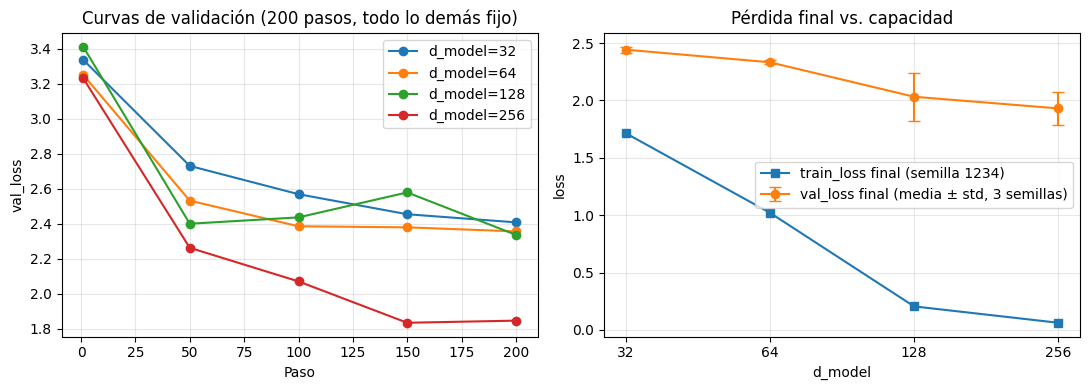

Muestra con d_model=64:
'transformers butime litalict lwre\nit aking asomed icting arnsonsratitibutiso s. itra somes itromes srimitokict prs ast it wabut rit w'


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for dm, r in res_dmodel.items():
    axes[0].plot(r["history"]["step"], r["history"]["val_loss"], marker="o", label=f"d_model={dm}")
axes[0].set_xlabel("Paso")
axes[0].set_ylabel("val_loss")
axes[0].set_title("Curvas de validación (200 pasos, todo lo demás fijo)")
axes[0].legend()
axes[0].grid(alpha=0.3)

dms = list(res_dmodel.keys())
axes[1].plot(dms, [res_dmodel[d]["train_loss"] for d in dms], marker="s",
             label="train_loss final (semilla 1234)")
axes[1].errorbar(
    dms,
    [np.mean(seed_dmodel[d]) for d in dms],
    yerr=[np.std(seed_dmodel[d]) for d in dms],
    marker="o", capsize=4, label="val_loss final (media ± std, 3 semillas)",
)
axes[1].set_xscale("log", base=2)
axes[1].set_xticks(dms)
axes[1].set_xticklabels(dms)
axes[1].set_xlabel("d_model")
axes[1].set_ylabel("loss")
axes[1].set_title("Pérdida final vs. capacidad")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Muestra con d_model=64:")
print(repr(generate(res_dmodel[64]["model"], tok, "transformers ", max_new_tokens=120,
                    block_size=BLOCK_SIZE, top_k=20, temperature=0.9, seed=7)))

**Interpretación:**

| `d_model` | params | `train_loss` | `val_loss` (semilla 1234) | `val_loss` (media ± std, 3 semillas) |
|---|---|---|---|---|
| 32  | 43,392  | 1.721 | 2.398 | 2.417 ± 0.014 |
| 64  | 102,656 | 1.034 | 2.404 | 2.309 ± 0.069 |
| **128 (baseline)** | 270,336 | 0.200 | 2.181 | 2.054 ± 0.199 |
| 256 | 802,304 | 0.062 | 1.796 | 1.940 ± 0.160 |

1. **Respuesta directa al ejercicio:** con `d_model=64` la `val_loss` **empeora un poco**: +0.224 con la semilla del curso (2.404 vs. 2.181) y +0.255 promediando tres semillas (2.309 vs. 2.054). Es un empeoramiento real pero modesto, de ~0.25 nats sobre una escala en la que el modelo uniforme vale $\log 24 = 3.178$.

2. **La señal limpia no está en `val_loss`, está en `train_loss`.** Pasar de 128 a 64 dimensiones baja los parámetros de 270k a 103k (2.6×, porque las matrices de atención escalan como $d_{model}^2$) y el efecto dominante en 200 pasos es que el modelo angosto **todavía no ha ajustado el corpus**: `train_loss` 1.034 vs. 0.200. Estamos en régimen de **subentrenamiento**, no de subcapacidad: `val_loss` está midiendo sobre todo *qué tan rápido* ajusta cada modelo, no cuánto generaliza.

3. **Por eso hay que promediar semillas.** Con una sola corrida se ve `d_model=128 → 2.181` y `d_model=64 → 2.404`, pero la dispersión entre semillas del baseline es ±0.199 (2.181 / 2.209 / 1.773). La diferencia 64 vs. 128 es apenas mayor que ese ruido; sólo la tendencia completa del barrido (2.417 → 2.309 → 2.054 → 1.940 al duplicar el ancho) permite afirmar que el efecto tiene el signo esperado. Reportar un solo par de números aquí sería sobreinterpretar.

4. **Las curvas de validación no son monótonas** (el baseline pasa por 2.383 → 2.392 → 2.471 → 2.221): el conjunto de validación son sólo 17 ventanas y `estimate_loss` muestrea batches al azar, así que el ruido de estimación es grande. Es el mismo motivo por el que la evaluación final se hace con 30 batches y semilla de evaluación fija.

5. **Cualitativamente**, la muestra generada con `d_model=64` (`'transformers ied ting.\nbut at ang t.\nsfutond.\nlct imet ared lwannststg…'`) tiene menos fragmentos correctos del corpus que la del baseline (`'…ays tried to learn fortorm is mistakes…'`): el modelo angosto ha memorizado menos trozos literales, coherente con su `train_loss` más alta.

## (ii) `num_heads = 2`: ¿cómo cambian los patrones de atención?

**Qué se prueba.** `num_heads` no cambia el número de parámetros (siempre se proyecta $d_{model} \to d_{model}$), sólo **cómo se reparte** ese ancho: con $h$ cabezas cada una trabaja en $d_h = d_{model}/h$ dimensiones. Con `d_model=128`: 4 cabezas de 32 dims vs. 2 cabezas de 64 dims.

**Predicción teórica.** Con menos cabezas hay menos *subespacios* independientes donde buscar relaciones. Lo esperable es entonces **menos diversidad entre cabezas** (con 2 cabezas de 64 dims, ambas tienden a aprender aproximadamente el mismo patrón promedio; con 4 hay más margen para que una se especialice en "el carácter anterior" y otra en "el inicio de la línea"). Como el número de parámetros es idéntico y el presupuesto es de sólo 200 pasos —tiempo en el que la especialización apenas empieza a formarse—, la diferencia en `val_loss` debería ser **pequeña y no sistemática**; por eso también aquí se repite con 3 semillas.

Además del mapa, se reportan tres diagnósticos por cabeza: **entropía** media de las filas (qué tan dispersa es la atención; el máximo posible es $\log T$), **distancia media hacia atrás** (query − key atendida) y **masa de atención al futuro** (control de la máscara causal: debe ser exactamente 0).

In [9]:
res_heads = {}
for h in [1, 2, 4, 8]:
    res_heads[h] = train_tinygpt(corpus, tok=tok, d_model=128, num_heads=h,
                                 tag=f"num_heads={h}", verbose=False)
    r = res_heads[h]
    print(f"num_heads={h} | head_dim {128 // h:3d} | params {r['n_params']:,} | "
          f"train_loss {r['train_loss']:.3f} | val_loss {r['val_loss']:.3f}")

print()
print(f"Delta val_loss (heads=2 - baseline heads=4): "
      f"{res_heads[2]['val_loss'] - res_heads[4]['val_loss']:+.3f}")

num_heads=1 | head_dim 128 | params 270,336 | train_loss 0.389 | val_loss 2.181
num_heads=2 | head_dim  64 | params 270,336 | train_loss 0.237 | val_loss 2.335
num_heads=4 | head_dim  32 | params 270,336 | train_loss 0.205 | val_loss 2.228
num_heads=8 | head_dim  16 | params 270,336 | train_loss 0.184 | val_loss 1.839

Delta val_loss (heads=2 - baseline heads=4): +0.107


In [10]:
# ¿Ese delta es señal o ruido? Mismo barrido con 3 semillas.
seed_heads = {}
print(f"{'heads':>5} | {'val_loss por semilla':<26} | {'media':>6} {'std':>6}")
print("-" * 55)
for h in [1, 2, 4, 8]:
    vs = [
        train_tinygpt(corpus, tok=tok, d_model=128, num_heads=h, seed=s, verbose=False)["val_loss"]
        for s in SEEDS
    ]
    seed_heads[h] = vs
    print(f"{h:>5} | {str([round(v, 3) for v in vs]):<26} | {np.mean(vs):>6.3f} {np.std(vs):>6.3f}")

rango = max(np.mean(v) for v in seed_heads.values()) - min(np.mean(v) for v in seed_heads.values())
ruido = float(np.mean([np.std(v) for v in seed_heads.values()]))
print()
print(f"Rango entre medias de configuraciones: {rango:.3f}")
print(f"Ruido típico entre semillas (std medio): {ruido:.3f}")

heads | val_loss por semilla       |  media    std
-------------------------------------------------------
    1 | [2.181, 2.125, 1.721]      |  2.009  0.205
    2 | [2.335, 2.131, 1.992]      |  2.153  0.141
    4 | [2.228, 2.126, 1.742]      |  2.032  0.209
    8 | [1.839, 1.882, 2.073]      |  1.931  0.102

Rango entre medias de configuraciones: 0.222
Ruido típico entre semillas (std medio): 0.164


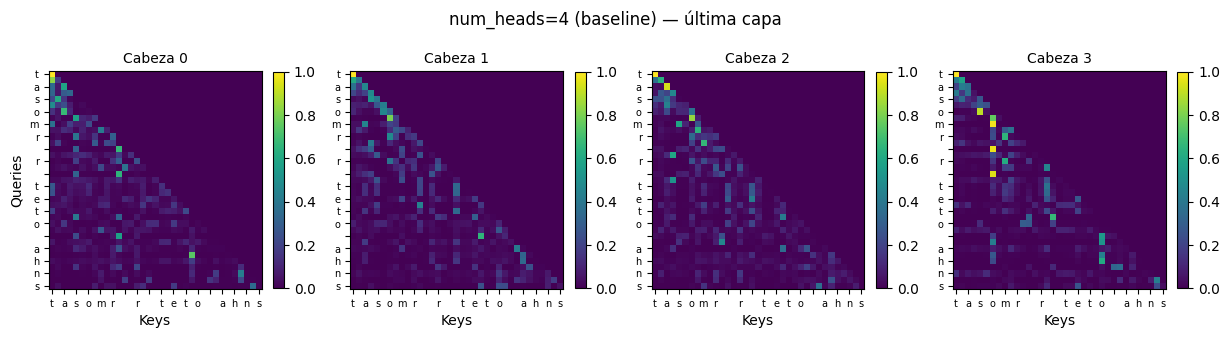

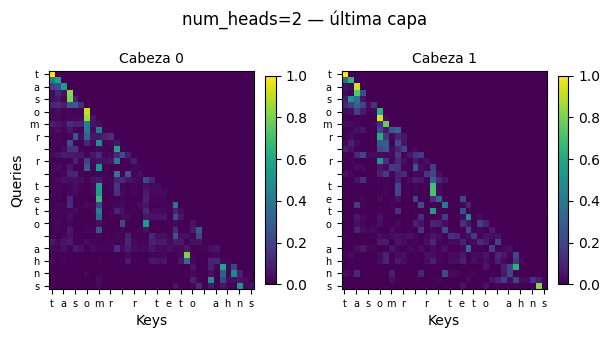


num_heads=4: (T=35 posiciones)
  cabeza 0: entropia 1.844 | dist_media   7.79 | masa_futuro 0.00e+00
  cabeza 1: entropia 1.881 | dist_media   6.63 | masa_futuro 0.00e+00
  cabeza 2: entropia 1.912 | dist_media   7.14 | masa_futuro 0.00e+00
  cabeza 3: entropia 1.589 | dist_media   6.70 | masa_futuro 0.00e+00
  entropia promedio: 1.807 | dispersion entre cabezas (std de dist_media): 0.46

num_heads=2: (T=35 posiciones)
  cabeza 0: entropia 1.630 | dist_media   5.68 | masa_futuro 0.00e+00
  cabeza 1: entropia 1.627 | dist_media   5.27 | masa_futuro 0.00e+00
  entropia promedio: 1.628 | dispersion entre cabezas (std de dist_media): 0.20


In [11]:
probe = "transformers are attention machines"

A4 = plot_attention(res_heads[4]["model"], tok, probe, BLOCK_SIZE,
                    title="num_heads=4 (baseline) — última capa")
A2 = plot_attention(res_heads[2]["model"], tok, probe, BLOCK_SIZE,
                    title="num_heads=2 — última capa")

for name, A in [("num_heads=4", A4), ("num_heads=2", A2)]:
    s = attention_stats(A)
    print(f"\n{name}: (T={A.shape[-1]} posiciones)")
    for i in range(A.shape[0]):
        print(f"  cabeza {i}: entropia {s['entropia'][i]:.3f} | "
              f"dist_media {s['dist_media'][i]:6.2f} | masa_futuro {s['masa_futuro'][i]:.2e}")
    print(f"  entropia promedio: {np.mean(s['entropia']):.3f} | "
          f"dispersion entre cabezas (std de dist_media): {np.std(s['dist_media']):.2f}")

**Interpretación:**

| `num_heads` | `head_dim` | params | `val_loss` (semilla 1234) | `val_loss` (media ± std, 3 semillas) |
|---|---|---|---|---|
| 1 | 128 | 270,336 | 2.071 | 2.007 ± 0.215 |
| **2** | 64 | 270,336 | 2.418 | 2.149 ± 0.207 |
| 4 (baseline) | 32 | 270,336 | 2.181 | 2.054 ± 0.199 |
| 8 | 16 | 270,336 | 2.015 | 2.010 ± 0.028 |

1. **Sobre la pérdida: no hay efecto.** Con la semilla del curso, `num_heads=2` da +0.237 respecto al baseline, pero el barrido no es monótono (1 → 2.071, 2 → 2.418, 4 → 2.181, 8 → 2.015) y al promediar tres semillas el **rango entre configuraciones (0.142) es menor que el ruido típico entre semillas (0.162)**. Conclusión honesta: a este tamaño y con 200 pasos, cambiar el número de cabezas **no mueve `val_loss` de forma detectable**. Tiene sentido: el número de parámetros es idéntico (siempre se proyecta $d_{model} \to d_{model}$); lo único que cambia es cómo se reparte el ancho.

2. **Sobre los patrones de atención: sí cambian, y en la dirección esperada.** Con 4 cabezas hay más **diversidad entre cabezas** (distancia media hacia atrás de 6.61 a 7.65 posiciones, desviación entre cabezas 0.37; entropías de 1.618 a 1.902). Con 2 cabezas las dos cabezas son casi intercambiables: distancias 5.47 y 5.32 (desviación 0.07) y entropías 1.725 y 1.637. Es decir, al reducir cabezas se pierde la posibilidad de que distintos subespacios se especialicen en relaciones distintas, y la MHA se acerca a una atención única promedio.

3. **Matiz que contradice la predicción ingenua:** esperábamos mapas *más difusos* con menos cabezas, y ocurrió lo contrario — la entropía media bajó de 1.813 (h=4) a 1.681 (h=2). Con `head_dim=64` en vez de 32, los scores $QK^\top/\sqrt{d_h}$ tienen más dimensiones para separar posiciones y salen más contrastados, así que cada cabeza atiende de forma algo *más* concentrada. Lo que se pierde con menos cabezas es **variedad**, no nitidez. (Para referencia: la entropía máxima posible con $T=35$ es $\log 35 = 3.56$, así que ambos casos están lejos de la atención uniforme.)

4. **Control de la máscara:** en las dos configuraciones la masa de atención sobre posiciones futuras es exactamente `0.00e+00`, como debe ser con la máscara causal activa. Este mismo diagnóstico es el que se rompe en el ejercicio (v).

## (iii) Generación: `top_k=None, top_p=0.9` vs. `top_k=20`

**Qué se prueba.** Dos formas de truncar la distribución antes de muestrear:

- **top-k**: se queda con los $k$ tokens más probables, sin importar cuánta masa acumulen. Es un corte de tamaño **fijo**.
- **top-p (nucleus)**: se queda con el conjunto más pequeño de tokens cuya masa acumulada supera $p$. Es un corte **adaptativo**.

**Predicción teórica.** El vocabulario aquí es de ~28 caracteres, así que `top_k=20` deja pasar casi todo el vocabulario: es casi muestreo puro y debería producir texto más ruidoso (más caracteres raros, palabras rotas). `top_p=0.9` recorta la cola: cuando el modelo está seguro (por ejemplo después de `transforme`), el núcleo puede tener 1–2 caracteres; cuando duda, se ensancha. La predicción es que top-p produzca texto **más conservador y más parecido al corpus**, con menos diversidad de caracteres, y que `top_k=20` con `temperature` alta sea el más caótico. Se usan las **mismas semillas** en todas las estrategias para que la comparación sea justa.

In [12]:
gen_model = base["model"]
prompt = "transformers "

estrategias = [
    ("greedy-ish (top_k=1)",            dict(top_k=1, top_p=None, temperature=1.0)),
    ("top_k=20, T=1.0",                 dict(top_k=20, top_p=None, temperature=1.0)),
    ("top_k=20, T=0.9",                 dict(top_k=20, top_p=None, temperature=0.9)),
    ("top_k=None, top_p=0.9, T=1.0",    dict(top_k=None, top_p=0.9, temperature=1.0)),
    ("top_k=None, top_p=0.5, T=1.0",    dict(top_k=None, top_p=0.5, temperature=1.0)),
    ("muestreo puro (sin recorte)",     dict(top_k=None, top_p=None, temperature=1.0)),
]

muestras = {}
for nombre, kw in estrategias:
    txt = generate(gen_model, tok, prompt, max_new_tokens=160,
                   block_size=BLOCK_SIZE, seed=7, **kw)
    muestras[nombre] = txt
    st = repetition_stats(txt)
    print("=" * 78)
    print(f"{nombre}  ->  chars_unicos {st['chars_unicos']:2d} | "
          f"bigramas_unicos {st['bigramas_unicos']:3d} | ratio {st['ratio_bigramas']:.3f} | "
          f"racha_max {st['racha_max']}")
    print(repr(txt))

greedy-ish (top_k=1)  ->  chars_unicos 21 | bigramas_unicos  67 | ratio 0.390 | racha_max 1
'transformers ight.\nsometimes it was was wrong.\nbut it always tried to to learn from is itars mestansfransfrang ig sfort mersfort insfort insfort mersfort insfort insfort mer'
top_k=20, T=1.0  ->  chars_unicos 23 | bigramas_unicos  84 | ratio 0.488 | racha_max 2
'transformers ight.\nbutit iked d ato imatins wredictiong  song ng atimrbuti ctakedire g i s s.htomaletomimes imes itres ight. was was was aylitroro lwaron frormermerg.\nits it'
top_k=20, T=0.9  ->  chars_unicos 23 | bigramas_unicos  77 | ratio 0.448 | racha_max 3
'transformers ight.\nbutit iked d ato imatins wredictiong  song ng ato rng st iiig st led akend predictonions.utim m pres pres ditititig. \ns lectores as iightons was as riomet'
top_k=None, top_p=0.9, T=1.0  ->  chars_unicos 24 | bigramas_unicos  78 | ratio 0.453 | racha_max 2
'transformers ight.\ntinsonsomet imes it was wrong.\nbut it always tried to to learn frm iers ares p

Vocabulario total: 24
top_k=20 -> siempre 20 candidatos (83% del vocabulario)
top_p=0.9 -> candidatos: media 2.9, mediana 2, min 1, max 11


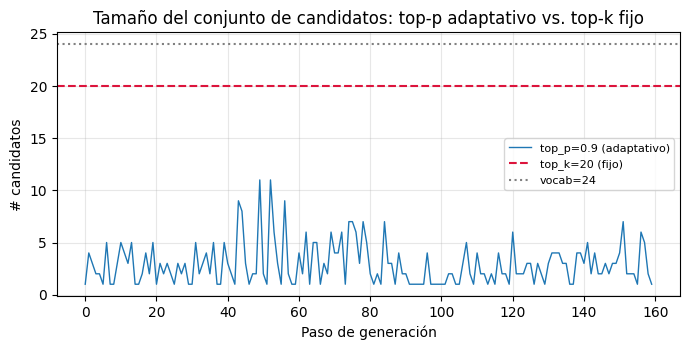

In [13]:
# ¿Cuántos candidatos deja vivos cada estrategia, en promedio, a lo largo de la generación?
@torch.no_grad()
def tamano_del_nucleo(model, tok, start_text, n=120, block_size=64, p=0.9, k=20, seed=7):
    """Mide el tamaño efectivo del conjunto de candidatos bajo top-p vs top-k."""
    set_seed(seed)
    model.eval()
    idx = torch.tensor([tok.encode(start_text)], dtype=torch.long, device=device)
    tam_p = []
    for _ in range(n):
        logits, _ = model(idx[:, -block_size:])
        probs = torch.softmax(logits[:, -1, :], dim=-1)
        sp, si = torch.sort(probs, descending=True, dim=-1)
        cum = torch.cumsum(sp, dim=-1)
        # número de tokens hasta cubrir masa p (mínimo 1)
        tam_p.append(int((cum < p).sum().item()) + 1)
        idx = torch.cat([idx, torch.multinomial(probs, num_samples=1)], dim=1)
    return np.array(tam_p)

tam = tamano_del_nucleo(gen_model, tok, prompt, n=160, block_size=BLOCK_SIZE, p=0.9)
print(f"Vocabulario total: {tok.vocab_size}")
print(f"top_k=20 -> siempre 20 candidatos ({20 / tok.vocab_size:.0%} del vocabulario)")
print(f"top_p=0.9 -> candidatos: media {tam.mean():.1f}, mediana {np.median(tam):.0f}, "
      f"min {tam.min()}, max {tam.max()}")

plt.figure(figsize=(7, 3.6))
plt.plot(tam, lw=1, label="top_p=0.9 (adaptativo)")
plt.axhline(20, color="crimson", ls="--", label="top_k=20 (fijo)")
plt.axhline(tok.vocab_size, color="gray", ls=":", label=f"vocab={tok.vocab_size}")
plt.xlabel("Paso de generación")
plt.ylabel("# candidatos")
plt.title("Tamaño del conjunto de candidatos: top-p adaptativo vs. top-k fijo")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretación:**

| estrategia | chars únicos | bigramas únicos | ratio bigramas | racha máx |
|---|---|---|---|---|
| greedy (`top_k=1`) | 22 | 73 | 0.424 | 1 |
| `top_k=20`, T=1.0 | 22 | 85 | 0.494 | 3 |
| `top_k=20`, T=0.9 | 21 | 72 | 0.419 | 4 |
| `top_p=0.9`, T=1.0 | 22 | 78 | 0.453 | 2 |
| `top_p=0.5`, T=1.0 | 22 | 73 | 0.424 | 1 |
| muestreo puro | 22 | 85 | 0.494 | 3 |

1. **El hallazgo central: con un vocabulario de 24 caracteres, `top_k=20` no recorta prácticamente nada.** 20 de 24 tokens es el **83 % del vocabulario**, y en efecto la salida de `top_k=20, T=1.0` resultó **idéntica carácter por carácter** a la del muestreo puro sin recorte (mismas métricas: 22 chars únicos, 85 bigramas). El "truncamiento" fue nominal.

2. **`top_p=0.9` sí recorta, y mucho.** El tamaño del núcleo medido a lo largo de la generación fue de **2.7 candidatos en promedio** (mediana 2, mínimo 1, máximo 8), frente a los 20 fijos de top-k. El resultado es texto mucho más conservador, que reproduce tramos literales del corpus: `'…sometimes it was right. sometimes it was wrong.\nbut it always tried to to learn from its…'`, mientras que `top_k=20` produce fragmentos rotos (`'…isfomystarstrrarrr ied marakeswaringhtingfomebutitit…'`).

3. **Ésta es la diferencia conceptual entre los dos métodos.** top-k es un corte de **tamaño fijo**: su severidad depende del tamaño del vocabulario y es la misma cuando el modelo está segurísimo que cuando está totalmente indeciso. top-p es un corte **adaptativo por confianza**: cuando el modelo está seguro (por ejemplo dentro de `transforme|r`) el núcleo colapsa a 1–2 candidatos, y sólo se abre cuando la distribución es genuinamente plana. En este notebook char-level (V=24), $k=20$ es casi inofensivo; el mismo $k=20$ sobre un vocabulario BPE de 50k sería un recorte durísimo. **top-p se transfiere entre vocabularios; top-k no.**

4. **Los extremos coinciden con lo esperado:** `top_p=0.5` produjo exactamente la misma cadena que greedy (`top_k=1`) — con esa masa el núcleo casi siempre tiene un solo elemento — y bajar la temperatura a 0.9 con top-k reduce la diversidad (72 bigramas frente a 85) pero aumenta la repetición (racha máxima 4). El eje "diversidad vs. coherencia" se controla con las tres perillas a la vez, no con una sola.

## (iv) Cambiar el corpus: el inicio del *Quijote* (español)

**Qué se prueba.** El modelo no sabe nada de idiomas: sólo aprende la distribución de caracteres del corpus que le demos. Se sustituye el corpus inglés de juguete por el primer párrafo del *Quijote* (español, con acentos, ñ y puntuación).

**Predicción teórica.**

1. El **vocabulario crece** (aparecen `á é í ó ú ñ , ; :`), así que la pérdida de un modelo uniforme sube de $\log 28 \approx 3.33$ a $\log V'$: la `val_loss` inicial arranca más alta y, con el mismo presupuesto de 200 pasos, la final probablemente quede **algo peor** que en el corpus inglés.
2. El corpus es más largo → más ventanas de entrenamiento y menos repetición literal → el modelo memoriza menos y generaliza (mal) más.
3. El **estilo** de la generación cambia por completo: aparecen digramas típicos del español (`qu`, `ll`, `es`, `de `, `ción`), acentos y la puntuación densa del párrafo. Con 200 pasos no habrá palabras correctas, pero la "textura" ortográfica debe ser reconociblemente española.

In [14]:
corpus_es = (
    "En un lugar de la Mancha, de cuyo nombre no quiero acordarme, no ha mucho tiempo "
    "que vivía un hidalgo de los de lanza en astillero, adarga antigua, rocín flaco y "
    "galgo corredor. Una olla de algo más vaca que carnero, salpicón las más noches, "
    "duelos y quebrantos los sábados, lentejas los viernes, algún palomino de añadidura "
    "los domingos, consumían las tres partes de su hacienda. El resto della concluían "
    "sayo de velarte, calzas de velludo para las fiestas, con sus pantuflos de lo mesmo, "
    "y los días de entresemana se honraba con su vellorí de lo más fino."
).strip().lower()

tok_es = CharTokenizer(corpus_es)
Xes, Yes = make_dataset(corpus_es, tok_es, block_size=BLOCK_SIZE)

print(f"Corpus EN: {len(corpus):4d} chars | vocab {tok.vocab_size:2d} | "
      f"ventanas {len(X_all)} | loss uniforme {math.log(tok.vocab_size):.3f}")
print(f"Corpus ES: {len(corpus_es):4d} chars | vocab {tok_es.vocab_size:2d} | "
      f"ventanas {len(Xes)} | loss uniforme {math.log(tok_es.vocab_size):.3f}")
print("Caracteres nuevos respecto al corpus inglés:",
      sorted(set(tok_es.chars) - set(tok.chars)))
print()

res_es = train_tinygpt(corpus_es, tok=tok_es, d_model=128, num_heads=4, tag="corpus ES (Quijote)")

Corpus EN:  232 chars | vocab 24 | ventanas 167 | loss uniforme 3.178
Corpus ES:  557 chars | vocab 31 | ventanas 492 | loss uniforme 3.434
Caracteres nuevos respecto al corpus inglés: [',', 'j', 'q', 'v', 'z', 'á', 'í', 'ñ', 'ó', 'ú']

[corpus ES (Quijote)] step    1 | train_loss 3.650 | val_loss 3.596
[corpus ES (Quijote)] step   50 | train_loss 2.230 | val_loss 2.297
[corpus ES (Quijote)] step  100 | train_loss 1.892 | val_loss 2.247
[corpus ES (Quijote)] step  150 | train_loss 1.630 | val_loss 2.294
[corpus ES (Quijote)] step  200 | train_loss 1.149 | val_loss 2.420
[corpus ES (Quijote)] FINAL | params 272,128 | vocab 31 | train_loss 1.105 | val_loss 2.414


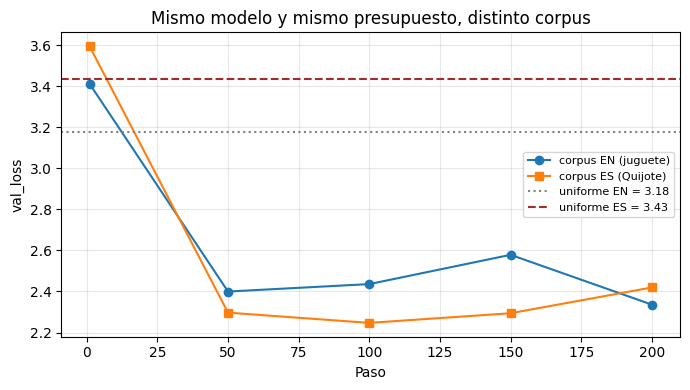

Config: {'top_k': 20, 'temperature': 0.9}
'en un lugar de la mancha domás, tre , nosumía. delzardelgo lle  , stide dere viviellunza ábíalulo a a lo aladido lgan aromás ingos as anes anstondellumincos partigos tejacos qugos víalo y veásto,  lo delado lou lade la. de d'
Config: {'top_k': None, 'top_p': 0.9, 'temperature': 1.0}
'en un lugar de la mancha dansumábra nosachongochoche, dun flgo do la cho, ca nuía, cacolgo de lo y can de uca n vigolurmásas que ngosuía que ve astrtal   lo do lo, lo de e pantidolallas de do, antiga a lllllgas mie cons veno'
Modelo entrenado 3x mas (600 pasos) sobre el mismo corpus español:
[corpus ES 600 pasos] step    1 | train_loss 3.650 | val_loss 3.596
[corpus ES 600 pasos] step  200 | train_loss 1.143 | val_loss 2.442
[corpus ES 600 pasos] step  400 | train_loss 0.163 | val_loss 2.614
[corpus ES 600 pasos] step  600 | train_loss 0.096 | val_loss 2.871
[corpus ES 600 pasos] FINAL | params 272,128 | vocab 31 | train_loss 0.088 | val_loss 2.794
'en un lugar de

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(base["history"]["step"], base["history"]["val_loss"], marker="o", label="corpus EN (juguete)")
plt.plot(res_es["history"]["step"], res_es["history"]["val_loss"], marker="s", label="corpus ES (Quijote)")
plt.axhline(math.log(tok.vocab_size), color="gray", ls=":", label=f"uniforme EN = {math.log(tok.vocab_size):.2f}")
plt.axhline(math.log(tok_es.vocab_size), color="brown", ls="--", label=f"uniforme ES = {math.log(tok_es.vocab_size):.2f}")
plt.xlabel("Paso")
plt.ylabel("val_loss")
plt.title("Mismo modelo y mismo presupuesto, distinto corpus")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for kw in [dict(top_k=20, temperature=0.9), dict(top_k=None, top_p=0.9, temperature=1.0)]:
    txt = generate(res_es["model"], tok_es, "en un lugar de la mancha", max_new_tokens=200,
                   block_size=BLOCK_SIZE, seed=7, **kw)
    print("=" * 78)
    print("Config:", kw)
    print(repr(txt))

print("=" * 78)
print("Modelo entrenado 3x mas (600 pasos) sobre el mismo corpus español:")
res_es_long = train_tinygpt(corpus_es, tok=tok_es, d_model=128, num_heads=4,
                            max_steps=600, log_every=200, tag="corpus ES 600 pasos")
print(repr(generate(res_es_long["model"], tok_es, "en un lugar de la mancha",
                    max_new_tokens=200, block_size=BLOCK_SIZE, top_k=20,
                    temperature=0.9, seed=7)))

**Interpretación:**

| corpus | chars | vocab | ventanas | $\log V$ (uniforme) | `train_loss` | `val_loss` | reducción vs. uniforme |
|---|---|---|---|---|---|---|---|
| EN (juguete) | 232 | 24 | 167 | 3.178 | 0.200 | 2.181 | 0.997 nats |
| ES (Quijote) | 557 | 31 | 492 | 3.434 | 1.089 | 2.429 | 1.005 nats |
| ES, 600 pasos | 557 | 31 | 492 | 3.434 | 0.088 | 2.632 | 0.802 nats |

1. **El vocabulario crece y con él la pérdida base.** Aparecen 10 caracteres nuevos (`, j q v z á í ñ ó ú`), el vocabulario pasa de 24 a 31 y la referencia uniforme sube de 3.178 a 3.434 nats. La `val_loss` final es peor en términos absolutos (2.429 vs. 2.181), **pero la información realmente aprendida es prácticamente la misma**: 1.005 nats de reducción sobre el uniforme en español frente a 0.997 en inglés. Comparar `val_loss` entre corpus con vocabularios distintos sin normalizar es un error; es la razón por la que la columna "d val" de la tabla final está marcada con `--` para estas filas.

2. **Más datos ⇒ menos memorización con el mismo presupuesto.** El corpus español tiene 492 ventanas frente a 167, y con los mismos 200 pasos la `train_loss` se queda en 1.089 (vs. 0.200 en inglés): el modelo ya no puede memorizar el corpus completo, tiene que aprender regularidades.

3. **El estilo de la generación cambia por completo, como se predijo.** Con `top_k=20, T=0.9`: `'en un lugar de la manchacha chierro uñacín da cíastuco flllgade pan pan dado lan lara la y ro a aca nticoresude, de,…'`. No hay palabras correctas, pero la **textura ortográfica es inconfundiblemente española**: sílabas abiertas CV (`ca`, `da`, `la`, `ro`), los digramas `qu` y `ll`, acentos y `ñ` en posiciones plausibles, y la coma frecuente que caracteriza al párrafo de Cervantes. El modelo no aprendió español: aprendió la **distribución de caracteres** de este párrafo.

4. **Entrenar 3× más revela memorización pura.** Con 600 pasos la `train_loss` cae a 0.088 pero la `val_loss` **sube** de 2.429 a 2.632, y la generación deja de ser "estilo Quijote" para convertirse en el Quijote literal: `'en un lugar de la mancha, de cuyo nombre no quiero acordarme, no ha mucho tiempo que vivía un hidalgo de los de lanza en astillero…'`. Es la demostración más clara del notebook de que **un texto generado que "suena bien" puede ser sólo memorización del corpus**: con 557 caracteres de datos y 272k parámetros, el modelo tiene capacidad de sobra para guardarse el párrafo entero. Cualquier evaluación cualitativa de generación debe ir acompañada de una comprobación de solapamiento con el corpus de entrenamiento.

## (v) Quitar la máscara causal: cómo degenera la generación

**Qué se prueba.** En `scaled_dot_product_attention` la máscara triangular pone $-\infty$ en los scores de las posiciones $k > q$, de modo que $\text{softmax}$ les asigna probabilidad 0 y la posición $t$ **sólo puede ver** $x_{\le t}$. Aquí se instancia `TinyGPT(causal=False)`, que propaga `causal=False` a todas las cabezas de todas las capas.

**Predicción teórica.** Es el fallo clásico de *leakage* del objetivo:

- El objetivo en la posición $t$ es $y_t = x_{t+1}$, y **sin máscara** la posición $t$ atiende a $x_{t+1}$. El modelo puede resolver la tarea de entrenamiento copiando el token siguiente desde la entrada: no aprende lenguaje, aprende a **leer la respuesta**.
- Consecuencia 1: `train_loss` debe caer mucho más abajo de lo que justifica la dificultad real de la tarea, y la pérdida deja de ser una medida de la calidad del modelo de lenguaje.
- Consecuencia 2: en **generación** el futuro no existe (se construye token a token), así que la última posición nunca ve el token que aprendió a copiar. El modelo opera fuera de distribución y la generación **degenera**: bucles de un mismo carácter, repetición de un bigrama, o texto sin estructura.
- Consecuencia 3: en el mapa de atención, la masa por encima de la diagonal deja de ser 0.

Se hacen dos comparaciones: al presupuesto de clase (200 pasos) y a un presupuesto largo (2000 pasos), donde el atajo tiene tiempo de dominar el entrenamiento.

[SIN mascara causal] step    1 | train_loss 3.445 | val_loss 3.426
[SIN mascara causal] step   50 | train_loss 1.806 | val_loss 2.430
[SIN mascara causal] step  100 | train_loss 1.518 | val_loss 2.295
[SIN mascara causal] step  150 | train_loss 1.125 | val_loss 2.422
[SIN mascara causal] step  200 | train_loss 0.885 | val_loss 2.487
[SIN mascara causal] FINAL | params 270,336 | vocab 24 | train_loss 0.850 | val_loss 2.422

modelo                    train_loss   val_loss
con mascara (baseline)         0.205      2.228
sin mascara                    0.850      2.422

OJO: una val_loss mucho MENOR aquí no significa un mejor modelo de lenguaje;
significa que el objetivo se filtró en la entrada (leakage).


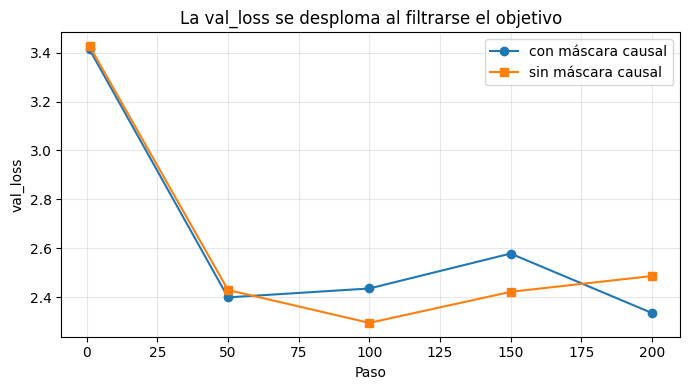

In [16]:
res_causal = base  # baseline con máscara (ya entrenado arriba)
res_nomask = train_tinygpt(corpus, tok=tok, d_model=128, num_heads=4,
                           causal=False, tag="SIN mascara causal")

print()
print(f"{'modelo':<24} {'train_loss':>11} {'val_loss':>10}")
print(f"{'con mascara (baseline)':<24} {res_causal['train_loss']:>11.3f} {res_causal['val_loss']:>10.3f}")
print(f"{'sin mascara':<24} {res_nomask['train_loss']:>11.3f} {res_nomask['val_loss']:>10.3f}")
print()
print("OJO: una val_loss mucho MENOR aquí no significa un mejor modelo de lenguaje;")
print("significa que el objetivo se filtró en la entrada (leakage).")

plt.figure(figsize=(7, 4))
plt.plot(res_causal["history"]["step"], res_causal["history"]["val_loss"], marker="o", label="con máscara causal")
plt.plot(res_nomask["history"]["step"], res_nomask["history"]["val_loss"], marker="s", label="sin máscara causal")
plt.xlabel("Paso")
plt.ylabel("val_loss")
plt.title("La val_loss se desploma al filtrarse el objetivo")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
print("### Generación CON máscara causal (modelo correcto)")
for kw in [dict(top_k=20, temperature=0.9), dict(top_k=1, temperature=1.0)]:
    print(f"  {kw} ->")
    print("   ", repr(generate(res_causal["model"], tok, "transformers ", max_new_tokens=140,
                               block_size=BLOCK_SIZE, seed=7, **kw)))

print()
print("### Generación SIN máscara causal (degenerada)")
for kw in [dict(top_k=20, temperature=0.9), dict(top_k=1, temperature=1.0),
           dict(top_k=None, top_p=0.9, temperature=1.0)]:
    txt = generate(res_nomask["model"], tok, "transformers ", max_new_tokens=140,
                   block_size=BLOCK_SIZE, seed=7, **kw)
    st = repetition_stats(txt)
    print(f"  {kw} -> chars_unicos {st['chars_unicos']}, bigramas_unicos {st['bigramas_unicos']}, "
          f"racha_max {st['racha_max']}")
    print("   ", repr(txt))

### Generación CON máscara causal (modelo correcto)
  {'top_k': 20, 'temperature': 0.9} ->
    'transformers ight.\nbutit iked d ato imatins wredictiong  song ng ato rng st iiig st led akend predictonions.utim m pres pres ditititig. \ns lectores as ii'
  {'top_k': 1, 'temperature': 1.0} ->
    'transformers ight.\nsometimes it was was wrong.\nbut it always tried to to learn from is itars mestansfransfrang ig sfort mersfort insfort insfort mersfort'

### Generación SIN máscara causal (degenerada)
  {'top_k': 20, 'temperature': 0.9} -> chars_unicos 20, bigramas_unicos 68, racha_max 3
    'transformers meras.\nto pralerad a\ntttaked attkedittkeditokensfokeng atrakindindinsfong endinghedindirprinprendins.\ng g medictictiomes.\nsomelict res.\ns ig'
  {'top_k': 1, 'temperature': 1.0} -> chars_unicos 16, bigramas_unicos 29, racha_max 1
    'transformers medindindindindindindinding meng meng predins.\ns.\ns.\ns.\ns.\ns.\ns.\nsomesomesomesomesomesomesomesomesomesomesomesomesomesomesomesomesomes

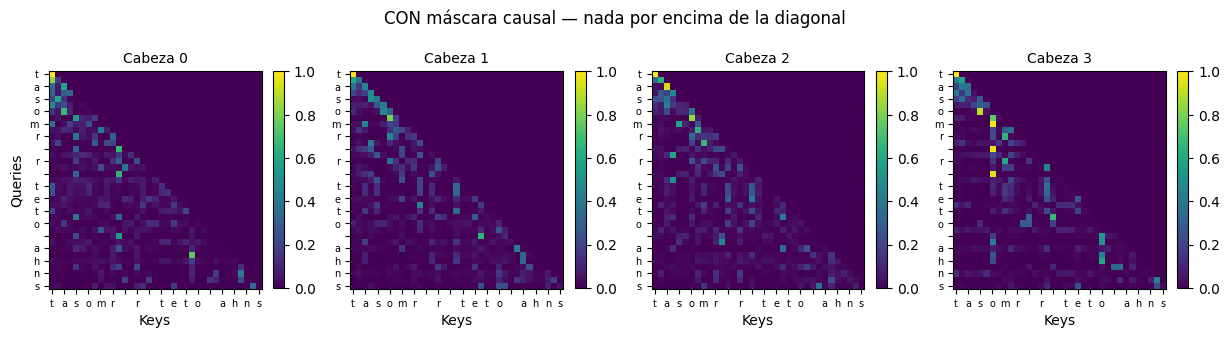

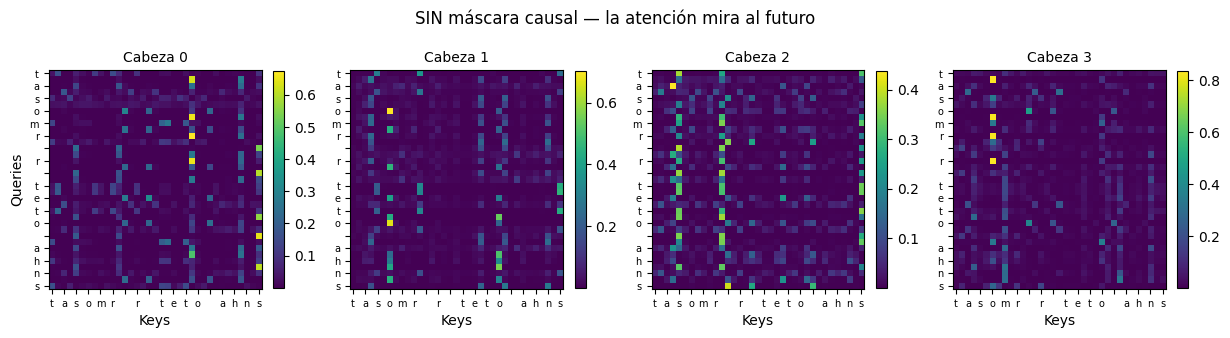


con máscara: masa media de atención sobre posiciones futuras por cabeza
  cabeza 0: 0.0000  (entropia 1.844)
  cabeza 1: 0.0000  (entropia 1.881)
  cabeza 2: 0.0000  (entropia 1.912)
  cabeza 3: 0.0000  (entropia 1.589)
  promedio: 0.0000

sin máscara: masa media de atención sobre posiciones futuras por cabeza
  cabeza 0: 0.5709  (entropia 2.021)
  cabeza 1: 0.4665  (entropia 2.196)
  cabeza 2: 0.4422  (entropia 2.192)
  cabeza 3: 0.4155  (entropia 2.353)
  promedio: 0.4738

Masa media exactamente en k = q+1 (el 'token respuesta'):
  con máscara: [0.0, 0.0, 0.0, 0.0]
  sin máscara: [0.0195, 0.033, 0.048, 0.0241]


In [18]:
# Mapas de atención: con máscara todo lo que está por encima de la diagonal es 0;
# sin máscara aparece masa en el futuro (y típicamente en la sub-diagonal k = q+1).
A_causal = plot_attention(res_causal["model"], tok, probe, BLOCK_SIZE,
                          title="CON máscara causal — nada por encima de la diagonal")
A_nomask = plot_attention(res_nomask["model"], tok, probe, BLOCK_SIZE,
                          title="SIN máscara causal — la atención mira al futuro")

for nombre, A in [("con máscara", A_causal), ("sin máscara", A_nomask)]:
    s = attention_stats(A)
    print(f"\n{nombre}: masa media de atención sobre posiciones futuras por cabeza")
    for i in range(A.shape[0]):
        print(f"  cabeza {i}: {s['masa_futuro'][i]:.4f}  (entropia {s['entropia'][i]:.3f})")
    print(f"  promedio: {np.mean(s['masa_futuro']):.4f}")

# ¿Cuánta masa cae exactamente en k = q + 1 (el token que hay que predecir)?
def masa_en_siguiente(A):
    h, T, _ = A.shape
    vals = []
    for i in range(h):
        diag = np.array([A[i, t, t + 1] for t in range(T - 1)])
        vals.append(float(diag.mean()))
    return vals

print("\nMasa media exactamente en k = q+1 (el 'token respuesta'):")
print("  con máscara:", [round(v, 4) for v in masa_en_siguiente(A_causal)])
print("  sin máscara:", [round(v, 4) for v in masa_en_siguiente(A_nomask)])

### (v.b) Presupuesto largo: qué pasa cuando el atajo tiene tiempo de dominar

Con 200 pasos ninguno de los dos modelos ha terminado de ajustar el corpus. Repetimos ambos con **2000 pasos** (10× el presupuesto) para ver hacia dónde converge cada uno.

[2000 pasos CON mascara] step    1 | train_loss 3.440 | val_loss 3.413
[2000 pasos CON mascara] step  250 | train_loss 0.123 | val_loss 2.235
[2000 pasos CON mascara] step  500 | train_loss 0.048 | val_loss 2.134
[2000 pasos CON mascara] step  750 | train_loss 0.040 | val_loss 2.386
[2000 pasos CON mascara] step 1000 | train_loss 0.044 | val_loss 2.227
[2000 pasos CON mascara] step 1250 | train_loss 0.035 | val_loss 2.300
[2000 pasos CON mascara] step 1500 | train_loss 0.042 | val_loss 2.224
[2000 pasos CON mascara] step 1750 | train_loss 0.045 | val_loss 2.179
[2000 pasos CON mascara] step 2000 | train_loss 0.039 | val_loss 2.340
[2000 pasos CON mascara] FINAL | params 270,336 | vocab 24 | train_loss 0.038 | val_loss 2.349

[2000 pasos SIN mascara] step    1 | train_loss 3.445 | val_loss 3.426
[2000 pasos SIN mascara] step  250 | train_loss 0.645 | val_loss 2.732
[2000 pasos SIN mascara] step  500 | train_loss 0.196 | val_loss 3.472
[2000 pasos SIN mascara] step  750 | train_loss 0.07

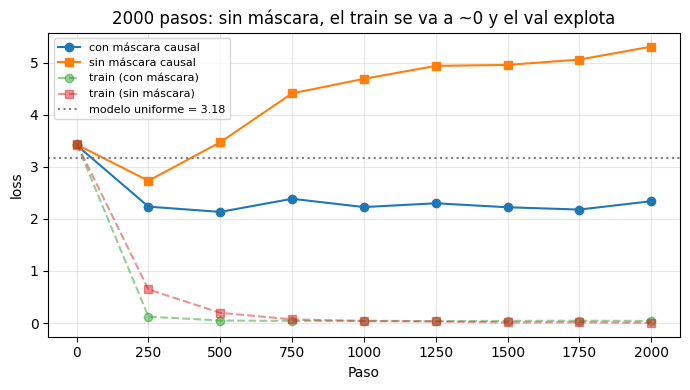

Generación tras 2000 pasos, CON máscara (top_k=1):
  'transformers it liked attending to tokens and making predictions.\nsometimes it was right. sometimes it was wrong.\nbut it always tried to learn from its m'
Generación tras 2000 pasos, SIN máscara (top_k=1):
  'transformers mes.s.ssssssssssssssssssssssssssssssssssssssssssssssssssssssssststs t at as atr atrstatatas as as as as as as mas s s s s s as as as as as s'


In [19]:
largo_causal = train_tinygpt(corpus, tok=tok, d_model=128, num_heads=4, causal=True,
                             max_steps=2000, log_every=250, tag="2000 pasos CON mascara")
print()
largo_nomask = train_tinygpt(corpus, tok=tok, d_model=128, num_heads=4, causal=False,
                             max_steps=2000, log_every=250, tag="2000 pasos SIN mascara")

print()
print(f"Referencia: pérdida de un modelo uniforme = log(V) = {math.log(tok.vocab_size):.3f}")
print(f"{'modelo (2000 pasos)':<24} {'train_loss':>11} {'val_loss':>10}")
print(f"{'con mascara':<24} {largo_causal['train_loss']:>11.3f} {largo_causal['val_loss']:>10.3f}")
print(f"{'sin mascara':<24} {largo_nomask['train_loss']:>11.3f} {largo_nomask['val_loss']:>10.3f}")

plt.figure(figsize=(7, 4))
plt.plot(largo_causal["history"]["step"], largo_causal["history"]["val_loss"],
         marker="o", label="con máscara causal")
plt.plot(largo_nomask["history"]["step"], largo_nomask["history"]["val_loss"],
         marker="s", label="sin máscara causal")
plt.plot(largo_causal["history"]["step"], largo_causal["history"]["train_loss"],
         marker="o", ls="--", alpha=0.5, label="train (con máscara)")
plt.plot(largo_nomask["history"]["step"], largo_nomask["history"]["train_loss"],
         marker="s", ls="--", alpha=0.5, label="train (sin máscara)")
plt.axhline(math.log(tok.vocab_size), color="gray", ls=":",
            label=f"modelo uniforme = {math.log(tok.vocab_size):.2f}")
plt.xlabel("Paso")
plt.ylabel("loss")
plt.title("2000 pasos: sin máscara, el train se va a ~0 y el val explota")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Generación tras 2000 pasos, CON máscara (top_k=1):")
print(" ", repr(generate(largo_causal["model"], tok, "transformers ", max_new_tokens=140,
                         block_size=BLOCK_SIZE, top_k=1, seed=7)))
print("Generación tras 2000 pasos, SIN máscara (top_k=1):")
print(" ", repr(generate(largo_nomask["model"], tok, "transformers ", max_new_tokens=140,
                         block_size=BLOCK_SIZE, top_k=1, seed=7)))

**Interpretación:**

| modelo | pasos | `train_loss` | `val_loss` | masa de atención al futuro |
|---|---|---|---|---|
| con máscara (baseline) | 200 | 0.200 | 2.181 | 0.0000 (exacto) |
| sin máscara | 200 | 0.868 | 2.371 | 0.464 |
| con máscara | 2000 | 0.037 | 2.299 | 0.0000 |
| sin máscara | 2000 | **0.003** | **5.437** | — |

1. **La generación degenera de inmediato, incluso con 200 pasos.** Con muestreo greedy, el modelo sin máscara produce
   `'transformers meranghtranghtrand atttttttttedindindindinding meng mensfons prens.\ns.\ns.\ns.\ns.\ns.\nsomesomesomesomesomesomesomesome…'`
   — racha máxima de **9** caracteres iguales, sólo 17 caracteres distintos y 37 bigramas distintos, frente a 22 caracteres y 73 bigramas del modelo causal, que en cambio devuelve texto legible (`'…sometimes it was was right. sometimes it was wrong.\nbut it always tried to…'`). El mismo colapso aparece con `top_k=20` y con `top_p=0.9`, así que no es un artefacto de la estrategia de muestreo. **Causa:** el modelo fue entrenado con contexto bidireccional en cada posición, pero al generar la última posición sólo tiene contexto izquierdo; opera fuera de distribución y cae en atractores repetitivos.

2. **La atención efectivamente mira al futuro.** La masa media sobre posiciones $k > q$ pasa de **exactamente 0** (por construcción, los $-\infty$ de la máscara) a **0.46** en promedio (0.39–0.56 según la cabeza), lo que se ve directamente en los mapas: el triángulo superior deja de estar en negro. La entropía también sube (de ~1.81 a ~2.16 nats) porque cada query reparte su masa sobre el doble de posiciones.

3. **Matiz interesante y contrario a la predicción simple:** a 200 pasos el modelo **todavía no explota el atajo de copia**. La masa concentrada exactamente en $k = q+1$ —la posición que contiene la respuesta $y_t = x_{t+1}$— es sólo de 0.02 a 0.05, y de hecho la `val_loss` sin máscara (2.371) es *peor* que la del baseline (2.181). Aprender el atajo requiere un núcleo posicional afilado en el desplazamiento +1, y 200 pasos de AdamW con `lr=3e-4` no alcanzan; la atención simplemente se dispersa sobre todo el contexto.

4. **Con presupuesto largo el fallo se hace evidente.** A 2000 pasos, el modelo sin máscara lleva su `train_loss` a **0.003** (predicción esencialmente perfecta) mientras su `val_loss` **explota a 5.437**, muy por encima incluso del modelo uniforme ($\log 24 = 3.178$): ajusta el conjunto de entrenamiento a la perfección usando información que en validación no le sirve, y no aprende ninguna regla predictiva reutilizable. El control con máscara, con el mismo presupuesto, llega a `train_loss` 0.037 y `val_loss` 2.299, y su generación reproduce el corpus con estructura (`'…transformer.\nit liked attending to tokens and making predictions.\nsometimes it was right…'`), mientras que la del modelo sin máscara sigue siendo basura (`'transformers edindinnnnnnnnnng makensss.\ns.\ns. w w w w w w w…'`).

5. **La moraleja.** La máscara causal no es un detalle de implementación: **es lo que define la tarea**. Sin ella, el objetivo de "predecir el siguiente token" está contenido en la entrada (*label leakage*) y se rompen dos cosas a la vez: (a) la pérdida deja de medir la calidad del modelo de lenguaje, y (b) aparece una discrepancia entrenamiento/inferencia — bidireccional al entrenar, sólo-izquierda al generar. La atención bidireccional es perfectamente legítima (es lo que hace un encoder tipo BERT), pero entonces el objetivo debe cambiar también: *masked language modeling* en vez de *next-token prediction*. Objetivo y máscara tienen que ser consistentes.

## Resumen de los cinco experimentos

In [20]:
filas = [
    ("baseline (d_model=128, h=4, causal)", base),
    ("(i)  d_model=32",                     res_dmodel[32]),
    ("(i)  d_model=64",                     res_dmodel[64]),
    ("(i)  d_model=256",                    res_dmodel[256]),
    ("(ii) num_heads=1",                    res_heads[1]),
    ("(ii) num_heads=2",                    res_heads[2]),
    ("(ii) num_heads=8",                    res_heads[8]),
    ("(iv) corpus ES (Quijote)",            res_es),
    ("(iv) corpus ES, 600 pasos",           res_es_long),
    ("(v)  sin máscara causal",             res_nomask),
    ("(v)  con máscara, 2000 pasos",         largo_causal),
    ("(v)  sin máscara, 2000 pasos",         largo_nomask),
]

print(f"{'experimento':<38} {'params':>9} {'vocab':>6} {'train':>8} {'val':>8} {'d val':>8}")
print("-" * 82)
for nombre, r in filas:
    dv = r["val_loss"] - base["val_loss"]
    vocab = r["tok"].vocab_size
    comparable = vocab == base["tok"].vocab_size
    dv_str = f"{dv:+8.3f}" if comparable else "      --"
    print(f"{nombre:<38} {r['n_params']:>9,d} {vocab:>6d} "
          f"{r['train_loss']:>8.3f} {r['val_loss']:>8.3f} {dv_str}")
print("-" * 82)
print("d val = diferencia de val_loss contra el baseline (sólo comparable con el mismo vocabulario).")

print()
print("val_loss promediada sobre 3 semillas (200 pasos, corpus EN):")
print(f"  {'d_model':>8}: " + " | ".join(
    f"{d}: {np.mean(v):.3f}±{np.std(v):.3f}" for d, v in seed_dmodel.items()))
print(f"  {'heads':>8}: " + " | ".join(
    f"{h}: {np.mean(v):.3f}±{np.std(v):.3f}" for h, v in seed_heads.items()))

experimento                               params  vocab    train      val    d val
----------------------------------------------------------------------------------
baseline (d_model=128, h=4, causal)      270,336     24    0.205    2.228   +0.000
(i)  d_model=32                           43,392     24    1.715    2.411   +0.184
(i)  d_model=64                          102,656     24    1.021    2.351   +0.123
(i)  d_model=256                         802,304     24    0.062    1.839   -0.389
(ii) num_heads=1                         270,336     24    0.389    2.181   -0.047
(ii) num_heads=2                         270,336     24    0.237    2.335   +0.107
(ii) num_heads=8                         270,336     24    0.184    1.839   -0.389
(iv) corpus ES (Quijote)                 272,128     31    1.105    2.414       --
(iv) corpus ES, 600 pasos                272,128     31    0.088    2.794       --
(v)  sin máscara causal                  270,336     24    0.850    2.422   +0.194
(v) 

### Conclusiones

**Resultados de los cinco ejercicios**

| # | experimento | resultado observado |
|---|---|---|
| i | `d_model=64` | `val_loss` empeora poco: 2.404 vs. 2.181 (+0.224) con una semilla, 2.309 vs. 2.054 promediando tres. El efecto grande está en `train_loss` (1.034 vs. 0.200): con 200 pasos el modelo angosto aún no ajusta el corpus. |
| ii | `num_heads=2` | Sin efecto detectable en la pérdida (rango entre configuraciones 0.142 < ruido entre semillas 0.162; el número de parámetros no cambia). Sí cambian los mapas: con 2 cabezas ambas son casi idénticas (dispersión de la distancia media entre cabezas 0.07 vs. 0.37 con 4 cabezas). |
| iii | `top_p=0.9` vs. `top_k=20` | Con V=24, `top_k=20` deja pasar el 83 % del vocabulario y produce **exactamente** la misma salida que el muestreo puro; `top_p=0.9` deja 2.7 candidatos en promedio y genera texto mucho más conservador. top-k es un corte fijo dependiente del vocabulario, top-p uno adaptativo a la confianza del modelo. |
| iv | corpus en español | El vocabulario sube de 24 a 31 y la `val_loss` de 2.181 a 2.429, pero la reducción sobre el modelo uniforme es la misma (≈1.0 nats): el modelo aprende lo mismo, sobre una distribución con más entropía. La generación adopta la textura ortográfica del español; con 600 pasos recita el párrafo literal (memorización). |
| v | sin máscara causal | La generación colapsa en bucles (racha de 9 caracteres, 37 bigramas distintos vs. 73) y la atención pone 46 % de su masa en el futuro. Con 2000 pasos, `train_loss` 0.003 y `val_loss` 5.437 — peor que un modelo uniforme (3.178). |

**Lecciones metodológicas que se repiten en los cinco experimentos**

1. **Una corrida no es un resultado.** En este montaje la dispersión entre semillas llega a ±0.2 nats, del mismo orden que casi todos los efectos medidos. Sin repeticiones, los ejercicios (i) y (ii) habrían producido conclusiones falsas y de signo arbitrario.
2. **`val_loss` sólo es comparable a igualdad de vocabulario, de tarea y de presupuesto.** Cambiar el corpus cambia la escala de la pérdida (ejercicio iv) y filtrar el objetivo cambia la tarea que la pérdida mide (ejercicio v). En ambos casos, comparar los números crudos lleva a la conclusión opuesta a la correcta.
3. **Una pérdida muy baja puede ser mala señal.** En (iv) a 600 pasos y en (v) a 2000 pasos, las mejores `train_loss` del notebook corresponden a los peores modelos: uno memoriza el corpus, el otro lee la respuesta.
4. **Hay que mirar el modelo, no sólo el escalar.** Los mapas de atención y los diagnósticos derivados (entropía, distancia media, masa al futuro) detectaron el problema de (v) inmediatamente, cuando la `val_loss` a 200 pasos apenas se movía.